# 用户价值分层与营销ROI分析

本项目基于用户消费、活跃和浏览行为构建 RFM-I 用户价值模型，主要完成：

1. 数据质量检查；
2. 用户行为特征构建；
3. 探索性数据分析；
4. RFM-I 评分；
5. 标准 RFM 用户分层；
6. 营销扩展标签识别；
7. 用户画像可视化；
8. ROI 情景模拟；
9. 分析结果导出。


## 1. 环境与路径配置

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = 'data/user_personalized_features.csv'
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


## 2. 数据加载与质量检查

检查数据规模、字段完整性、缺失值、重复用户和明显的年龄异常值。


In [ ]:
require_columns = [
    'User_ID',
    'Age',
    'Income',
    'Last_Login_Days_Ago',
    'Purchase_Frequency',
    'Average_Order_Value',
    'Total_Spending',
    'Time_Spent_on_Site_Minutes',
    'Pages_Viewed'
]

def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

    missing_columns = [col for col in require_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f'数据缺少必要字段: {missing_columns}')

    print(f'数据规模: {df.shape[0]} 行 x {df.shape[1]} 列')
    print(f'缺失值总数: {df.isnull().sum().sum()}')
    print(f'重复用户数: {df["User_ID"].duplicated().sum()}')

    age_outliers = df[
        (df['Age'] < 10) | (df['Age'] > 100)
    ].shape[0]
    print(f'年龄异常值: {age_outliers}')

    return df

df = load_and_preprocess(DATA_PATH)
display(df.head())


数据规模: 1000 行 x 14 列
缺失值总数: 0
重复用户数: 0
年龄异常值: 0


,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


## 3. 行为特征构建

经典 RFM 模型：
- **R（Recency，最近活跃/最近消费）**
- **F（Frequency，购买频率）**
- **M（Monetary，消费金额）**

扩展指标：
- **I_Score（意向深度）**：浏览时长和浏览页数各占 50%；
- **Friction（决策摩擦）**：浏览页数 ÷（购买频率 + 1），识别“浏览较多但购买较少”的用户；
- **Income_Level（收入层级）**：按照收入的 33% 和 66% 分位点划分低、中、高收入层级。

In [9]:
# 将不同指标统一转换为0—100分
def min_max_normalize(series, reverse=False):
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series(50.0, index=series.index)
    norm = (series - min_val) / (max_val - min_val) * 100
    return 100 - norm if reverse else norm

def feature_engineering(df):
    result = df.copy()

    # 用户浏览行为意向
    result['Time_Spent_Norm'] = min_max_normalize(result['Time_Spent_on_Site_Minutes'])
    result['Pages_Viewed_Norm'] = min_max_normalize(result['Pages_Viewed'])
    result['I_Score'] = (0.5 * result['Time_Spent_Norm'] + 0.5 * result['Pages_Viewed_Norm'])

    # 浏览较多但购买较少时，决策摩擦较高
    result['Friction'] = ( result['Pages_Viewed'] / (result['Purchase_Frequency'] + 1))

    # 收入层级
    income_33 = result['Income'].quantile(0.33)
    income_66 = result['Income'].quantile(0.66)

    def classify_income(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'

    result['Income_Level'] = ( result['Income'].apply(classify_income))

    print(
        f'I_Score范围: '
        f'[{result["I_Score"].min():.2f}, '
        f'{result["I_Score"].max():.2f}]'
    )
    print(
        f'Friction范围: '
        f'[{result["Friction"].min():.2f}, '
        f'{result["Friction"].max():.2f}]'
    )
    print(
        'Income_Level分布:',
        result['Income_Level'].value_counts().to_dict()
    )

    return result

df = feature_engineering(df)
df[['User_ID', 'I_Score', 'Friction', 'Income_Level']].head()


I_Score范围: [0.00, 98.83]
Friction范围: [0.10, 49.00]
Income_Level分布: {'High': 340, 'Low': 330, 'Medium': 330}


,User_ID,I_Score,Friction,Income_Level
0,#1,87.285385,4.750000,Low
1,#2,76.638400,5.000000,High
2,#3,25.460637,0.500000,High
3,#4,73.136516,7.250000,Medium
4,#5,13.646357,1.666667,Low


## 4. 探索性数据分析（EDA）

观察消费、收入、活跃和浏览行为的分布，并分析：

- 浏览行为与购买频率的相关关系；
- 高摩擦用户的主要特征；
- 高收入但消费较低的潜在用户规模；

为后续分层规则提供依据。

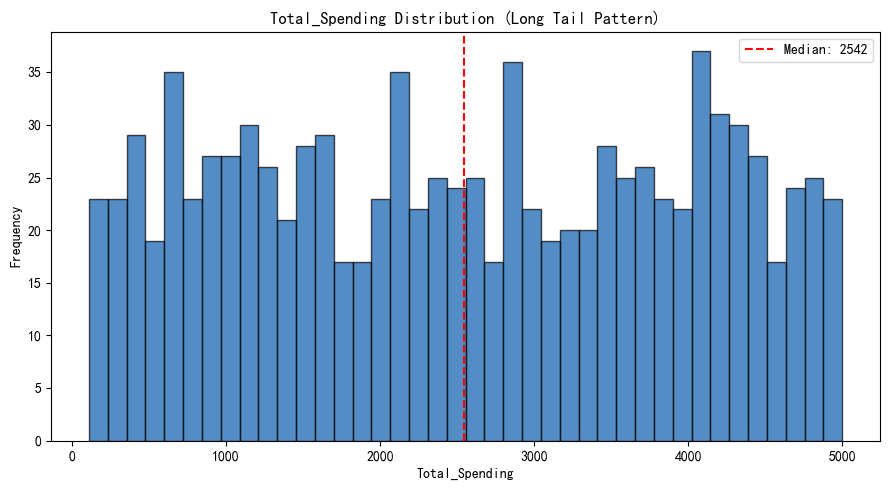

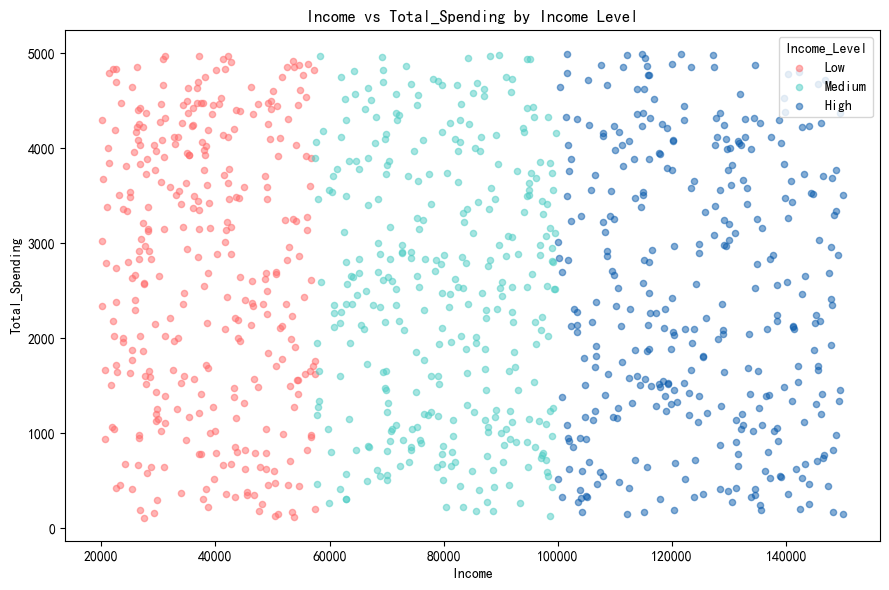

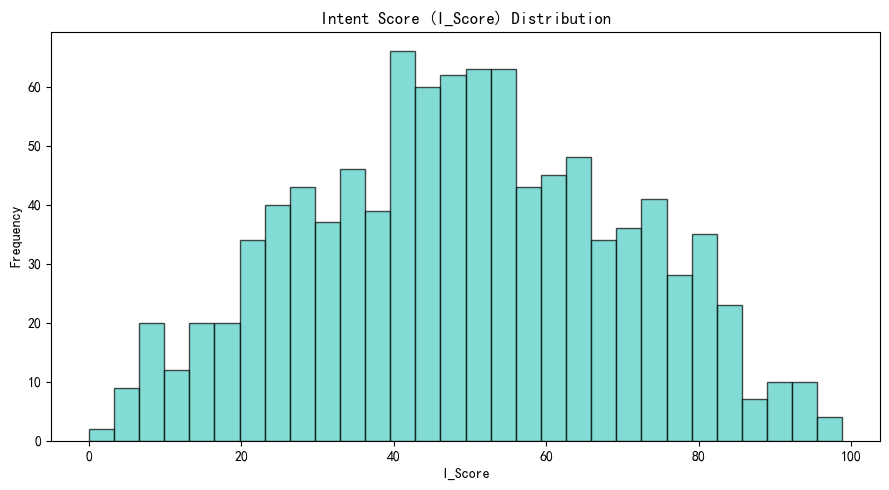

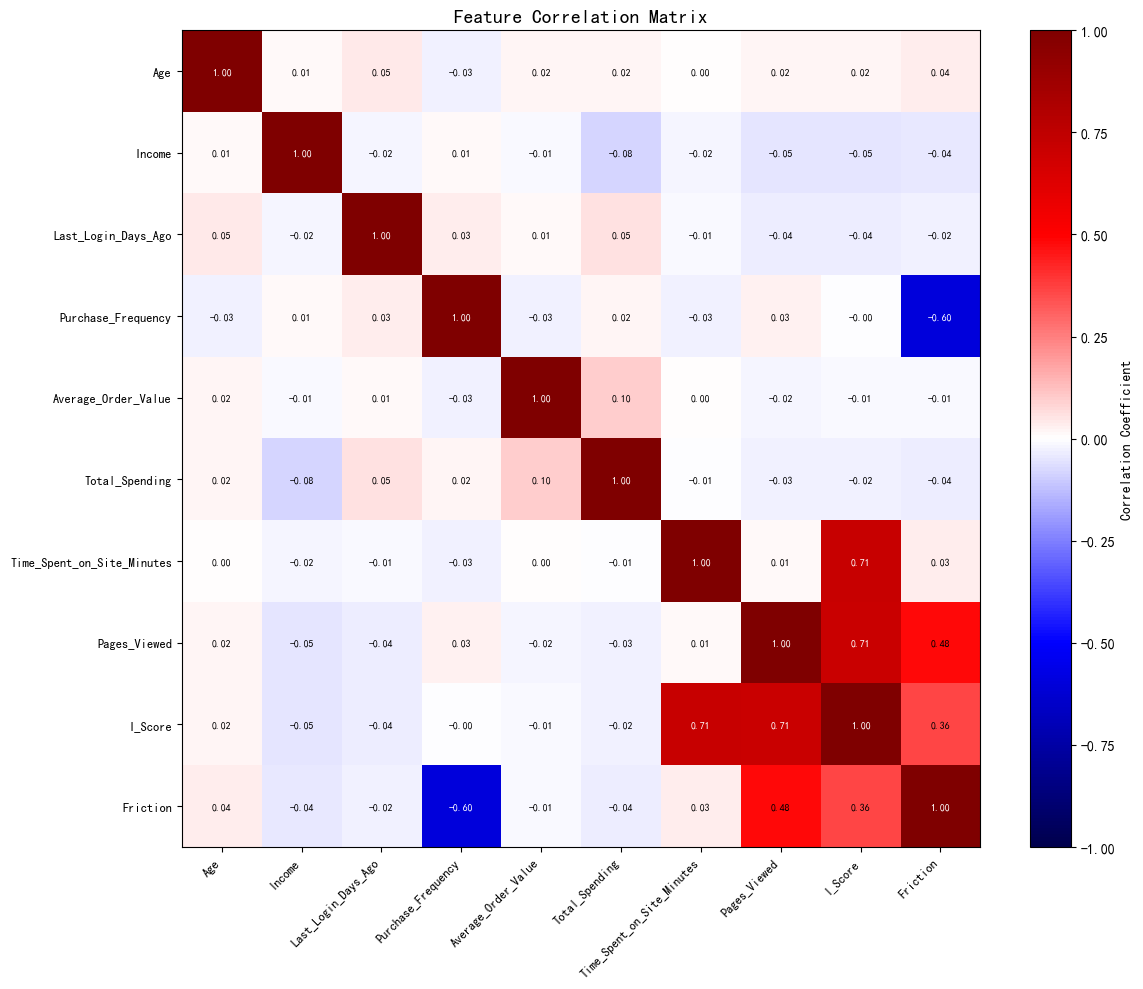


关键相关性分析:
浏览时长vs购买频率 相关系数: -0.028
浏览页数vs购买频率 相关系数: 0.026

高摩擦用户（前25%）特征:
平均浏览页数: 34.3
平均购买频率: 1.6
平均消费金额: 2514

高收入低消费用户:
用户数: 184
占高收入用户比例: 54.1%


In [10]:
def perform_eda(df, output_dir):
    colors_map = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}

    save_dir = os.path.join(output_dir, "EDA_result")
    os.makedirs(save_dir, exist_ok=True)

    # 总消费金额分布
    plt.figure(figsize=(9, 5))
    plt.hist(df['Total_Spending'],bins=40,alpha=0.7,color='#0B5CAD',edgecolor='black')
    median_val = df['Total_Spending'].median()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.0f}')

    plt.title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    plt.xlabel('Total_Spending')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, 'total_spending_distribution.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # 收入与消费金额关系
    plt.figure(figsize=(9, 6))
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        plt.scatter(subset['Income'], subset['Total_Spending'], alpha=0.5, label=level, c=colors_map[level],s=20)

    plt.title('Income vs Total_Spending by Income Level', fontsize=12)
    plt.xlabel('Income')
    plt.ylabel('Total_Spending')
    plt.legend(title='Income_Level')
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, 'income_spending_scatter.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # I_Score分布
    plt.figure(figsize=(9, 5))
    plt.hist( df['I_Score'], bins=30, alpha=0.7, color='#4ECDC4', edgecolor='black')

    plt.title('Intent Score (I_Score) Distribution', fontsize=12)
    plt.xlabel('I_Score')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, 'i_score_distribution.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # 数值特征相关性矩阵
    numeric_cols = [
        'Age',
        'Income',
        'Last_Login_Days_Ago',
        'Purchase_Frequency',
        'Average_Order_Value',
        'Total_Spending',
        'Time_Spent_on_Site_Minutes',
        'Pages_Viewed',
        'I_Score',
        'Friction'
    ]

    corr_matrix = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='seismic', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)

    for row in range(len(numeric_cols)):
        for col in range(len(numeric_cols)):
            val = corr_matrix.iloc[row, col]
            text_color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(
                col, row, f'{val:.2f}',
                ha='center', va='center',
                fontsize=7, color=text_color
            )

    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax, label='Correlation Coefficient')
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, 'correlation_matrix.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # 浏览行为与购买频率的相关关系
    time_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    page_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])

    print('\n关键相关性分析:')
    print(f"浏览时长vs购买频率 相关系数: {time_corr:.3f}")
    print(f"浏览页数vs购买频率 相关系数: {page_corr:.3f}")

    # 高摩擦用户
    friction_threshold = df['Friction'].quantile(0.75)
    high_friction = df[df['Friction'] > friction_threshold]

    print('\n高摩擦用户（前25%）特征:')
    print(f"平均浏览页数: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"平均购买频率: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"平均消费金额: {high_friction['Total_Spending'].mean():.0f}")

    # 高收入低消费用户
    high_income = df[df['Income_Level'] == 'High']
    spending_median = df['Total_Spending'].median()
    high_income_low_spend = high_income[high_income['Total_Spending'] < spending_median]

    if len(high_income) > 0:
        ratio = len(high_income_low_spend) / len(high_income) * 100
    else:
        ratio = 0

    print('\n高收入低消费用户:')
    print(f'用户数: {len(high_income_low_spend)}')
    print(f'占高收入用户比例: {ratio:.1f}%')

    return {
        'time_purchase_corr': time_corr,
        'pages_purchase_corr': page_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }

eda_results = perform_eda(df, OUTPUT_DIR)

## 5. RFM-I 价值评分

- **R**：距离最近登录天数越小，得分越高（使用 `Last_Login_Days_Ago` 近似衡量 R（Recency，最近活跃程度））；
- **F**：购买频率越高，得分越高；
- **M**：总消费金额越高，得分越高；
- **I**：作为行为意向增强项。

`RFM_Score = 0.2 × R + 0.3 × F + 0.5 × M`

`Final_Score = RFM_Score × (1 + 0.2 × I_Score / 100)`

权重分别设置为 `R=20%`、`F=30%`、`M=50%`


In [11]:
def build_rfm_i_score(df):
    result = df.copy()

    result['R_Score'] = min_max_normalize( result['Last_Login_Days_Ago'], reverse=True)
    result['F_Score'] = min_max_normalize( result['Purchase_Frequency'])
    result['M_Score'] = min_max_normalize( result['Total_Spending'])
    result['RFM_Score'] = ( 0.2 * result['R_Score'] + 0.3 * result['F_Score'] + 0.5 * result['M_Score'])

    # I_Score最高为100，因此最多将RFM得分提高约20%
    result['I_Weight'] = 0.2 * (result['I_Score'] / 100)
    result['Final_Score'] = result['RFM_Score'] * (1 + result['I_Weight'])

    return result

df = build_rfm_i_score(df)
df[['User_ID', 'R_Score', 'F_Score', 'M_Score','I_Score', 'RFM_Score', 'Final_Score']].head()


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


## 6. 用户分层

**基础 RFM 标签**

- 重要价值用户；
- 重要保持用户；
- 重要发展用户；
- 重要挽留用户；
- 一般价值用户；
- 一般保持用户；
- 一般发展用户；
- 低价值用户。

**扩展标签**

在基础 RFM 标签上，结合收入层级、I_Score 和 Friction 识别核心、流失和待转化用户。


In [ ]:
def classify_users(df):
    result = df.copy()

    r_threshold = result['R_Score'].median()
    f_threshold = result['F_Score'].median()
    m_threshold = result['M_Score'].median()
    friction_threshold = result['Friction'].quantile(0.75)

    def classify_rfm(row):
        r_high = row['R_Score'] >= r_threshold
        f_high = row['F_Score'] >= f_threshold
        m_high = row['M_Score'] >= m_threshold

        if r_high and f_high and m_high:
            return '重要价值用户'
        elif not r_high and f_high and m_high:
            return '重要保持用户'
        elif r_high and not f_high and m_high:
            return '重要发展用户'
        elif not r_high and not f_high and m_high:
            return '重要挽留用户'
        elif r_high and f_high and not m_high:
            return '一般价值用户'
        elif not r_high and f_high and not m_high:
            return '一般保持用户'
        elif r_high and not f_high and not m_high:
            return '一般发展用户'
        else:
            return '低价值用户'

    result['RFM_Segment'] = result.apply(
        classify_rfm,
        axis=1
    )

    def classify_marketing_segment(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']
        friction = row['Friction']
        rfm_segment = row['RFM_Segment']

        # 最优先识别核心价值用户
        if (
            rfm_segment == '重要价值用户'
            and f >= 70
            and m >= 70
            and i >= 60
        ):
            return '核心VIP'

        # 历史价值较高，但最近活跃度较低
        if (
            r < r_threshold
            and m >= m_threshold
            and income == 'High'
        ):
            return '高潜流失用户'

        # 最近不活跃、当前价值较低，但收入和浏览意向较高
        if (
            r < r_threshold
            and f < f_threshold
            and m < m_threshold
            and income == 'High'
            and i >= 60
        ):
            return '高潜沉睡用户'

        # 浏览意向和决策摩擦都较高
        if (
            i >= 80
            and friction >= friction_threshold
            and f < f_threshold
        ):
            return '犹豫型潜力用户'

        # 低收入但浏览意向较高
        if (
            income == 'Low'
            and i >= 70
            and f < f_threshold
        ):
            return '低收入高意向用户'

        # 浏览意向较高，但当前购买和消费较低
        if (
            i >= 70
            and f < f_threshold
            and m < m_threshold
        ):
            return '高意向待转化用户'

        # 当前价值和行为意向都较低
        if (
            rfm_segment == '低价值用户'
            and i < 40
        ):
            return '低意向低价值用户'

        return rfm_segment

    result['User_Segment'] = result.apply(
        classify_marketing_segment,
        axis=1
    )

    rfm_summary = (
        result.groupby('RFM_Segment')
        .agg(
            用户数=('User_ID', 'count'),
            平均消费金额=('Total_Spending', 'mean'),
            平均购买频率=('Purchase_Frequency', 'mean'),
            平均意向分=('I_Score', 'mean'),
            平均综合分=('Final_Score', 'mean')
        )
        .round(2)
    )
    rfm_summary['占比(%)'] = ( rfm_summary['用户数'] / len(result) * 100).round(1)
    rfm_summary = rfm_summary.sort_values( '用户数', ascending=False)

    segment_summary = (
        result.groupby('User_Segment')
        .agg(
            用户数=('User_ID', 'count'),
            平均消费金额=('Total_Spending', 'mean'),
            平均购买频率=('Purchase_Frequency', 'mean'),
            平均意向分=('I_Score', 'mean'),
            平均收入=('Income', 'mean'),
            平均综合分=('Final_Score', 'mean')
        )
        .round(2)
    )
    segment_summary['占比(%)'] = ( segment_summary['用户数'] / len(result) * 100).round(1)
    segment_summary = segment_summary.sort_values( '用户数', ascending=False)

    thresholds = pd.Series({
        'R中位数阈值': r_threshold,
        'F中位数阈值': f_threshold,
        'M中位数阈值': m_threshold,
        'Friction前25%阈值': friction_threshold
    }).round(2)

    return result, rfm_summary, segment_summary, thresholds

df, rfm_summary, segment_summary, segment_thresholds = (classify_users(df))

print('分层阈值:')
display(segment_thresholds)
print('标准RFM分层:')
display(rfm_summary)
print('营销扩展标签:')
display(segment_summary)


分层阈值:


R中位数阈值            46.43
F中位数阈值            55.56
M中位数阈值            49.72
Friction前25%阈值     7.75
dtype: float64

标准RFM分层:


,用户数,平均消费金额,平均购买频率,平均意向分,平均综合分,占比(%)
RFM_Segment,,,,,,
重要价值用户,149,3812.60,6.96,49.89,82.37,14.9
一般发展用户,135,1287.76,2.05,52.19,37.05,13.5
一般保持用户,129,1374.59,7.02,45.22,44.14,12.9
一般价值用户,128,1296.02,6.91,49.94,54.48,12.8
重要保持用户,122,3784.66,6.93,49.40,71.21,12.2
重要挽留用户,117,3878.01,2.00,47.09,54.06,11.7
重要发展用户,112,3674.01,1.97,50.17,63.42,11.2
低价值用户,108,1304.40,2.10,48.66,26.28,10.8


营销扩展标签:


,用户数,平均消费金额,平均购买频率,平均意向分,平均收入,平均综合分,占比(%)
User_Segment,,,,,,,
重要价值用户,135,3763.64,6.81,47.40,84577.90,80.96,13.5
一般保持用户,129,1374.59,7.02,45.22,78213.23,44.14,12.9
一般价值用户,128,1296.02,6.91,49.94,86358.71,54.48,12.8
一般发展用户,102,1316.34,2.00,42.98,89411.89,36.78,10.2
重要发展用户,95,3661.00,2.01,44.76,79842.00,62.95,9.5
重要保持用户,83,3730.36,6.87,50.52,56164.96,70.27,8.3
重要挽留用户,73,3840.37,2.04,44.89,60392.77,53.62,7.3
高潜流失用户,71,3957.14,4.82,43.71,121667.96,65.09,7.1
低价值用户,44,1364.34,2.00,53.01,83990.86,26.83,4.4


## 7. 用户画像可视化

分别展示：

- 标准 RFM 八类用户数量；
- 营销扩展标签数量；
- 用户数最多的 8 个营销群体的 R、F、M、I 雷达图。


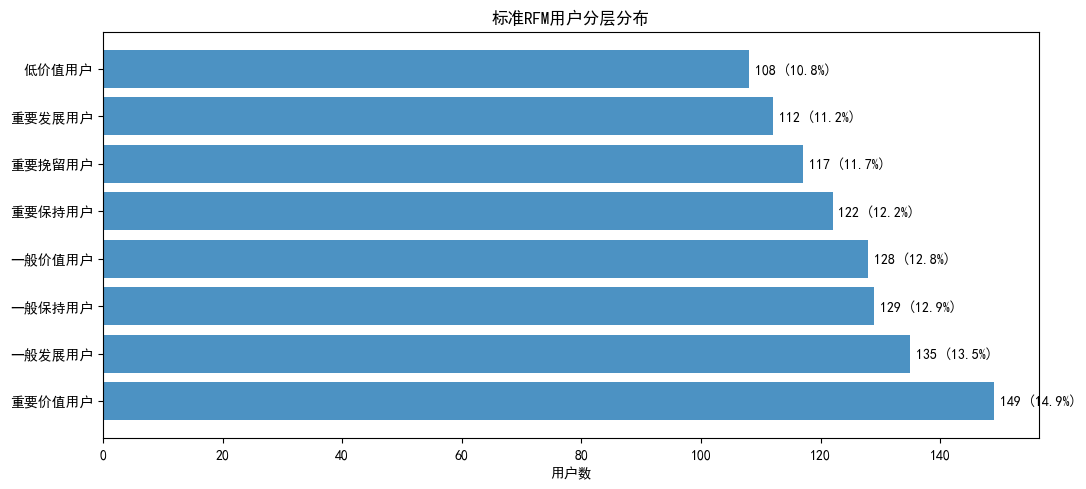

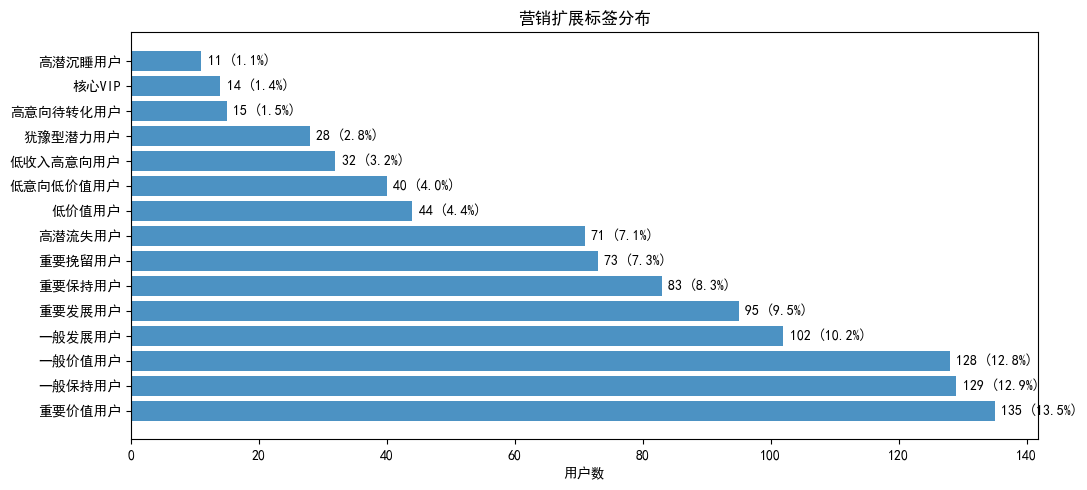

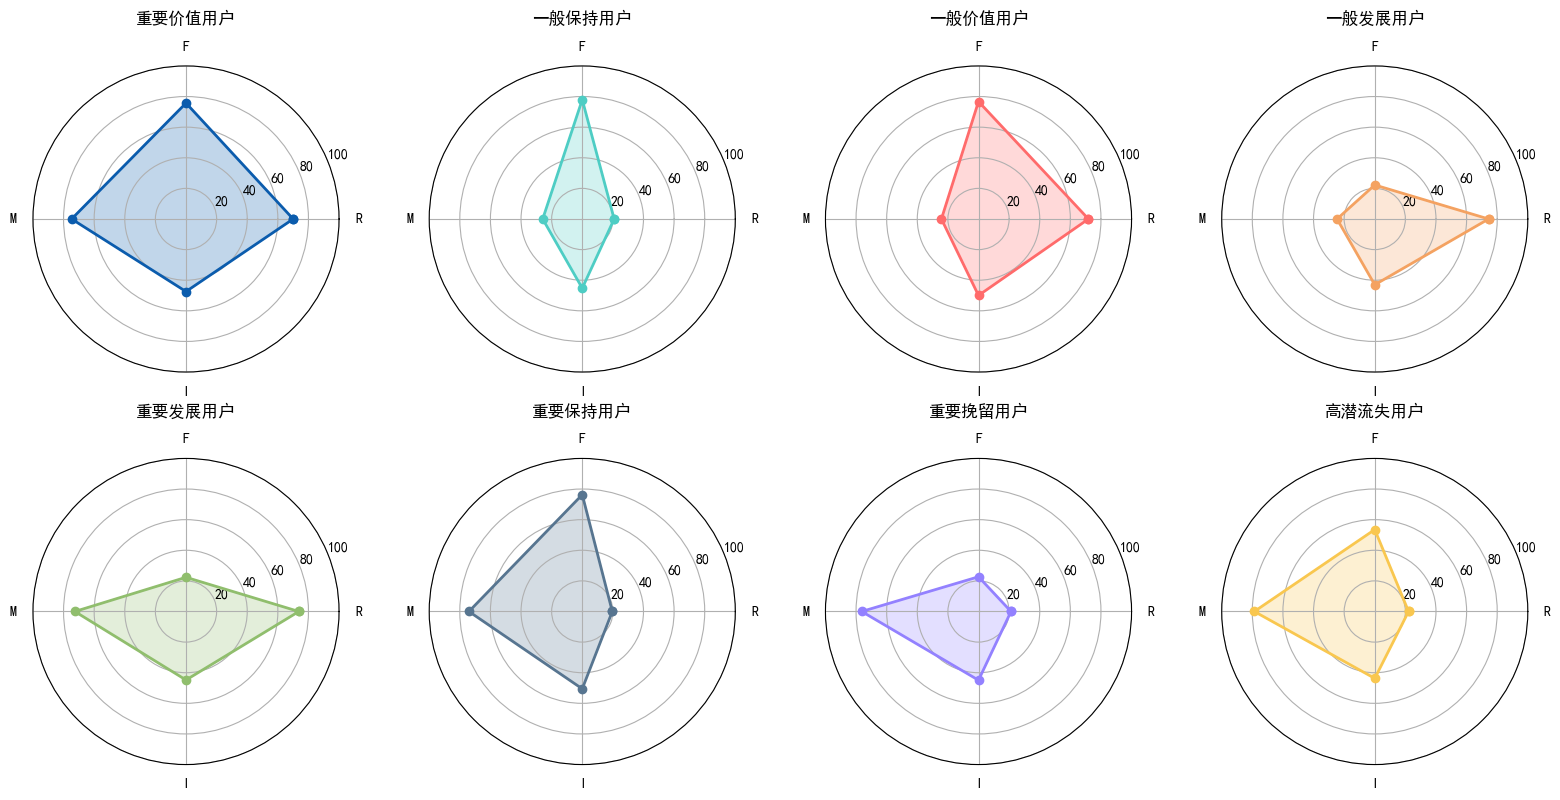

In [13]:
def plot_segment_portraits(df, output_dir):
    save_dir = os.path.join(output_dir, "segment_result")
    os.makedirs(save_dir, exist_ok=True)

    # 标准RFM分层分布
    rfm_counts = df['RFM_Segment'].value_counts()

    plt.figure(figsize=(11, 5))
    bars = plt.barh( rfm_counts.index, rfm_counts.values, alpha=0.8)
    plt.title('标准RFM用户分层分布')
    plt.xlabel('用户数')

    for bar, count in zip(bars, rfm_counts.values):
        plt.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{count} ({count / len(df) * 100:.1f}%)',
            va='center'
        )

    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, 'rfm_segment_distribution.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # 营销扩展标签分布
    segment_counts = df['User_Segment'].value_counts()

    plt.figure(figsize=(11, 5))
    bars = plt.barh( segment_counts.index, segment_counts.values, alpha=0.8)
    plt.title('营销扩展标签分布')
    plt.xlabel('用户数')

    for bar, count in zip(bars, segment_counts.values):
        plt.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{count} ({count / len(df) * 100:.1f}%)',
            va='center'
        )

    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, 'user_segment_distribution.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # 分层雷达图
    top_segments = (segment_counts.head(8).index.tolist())
    metrics = ['R_Score', 'F_Score', 'M_Score', 'I_Score']
    labels = ['R', 'F', 'M', 'I']

    segment_means = (
        df[df['User_Segment'].isin(top_segments)]
        .groupby('User_Segment')[metrics]
        .mean()
        .loc[top_segments]
    )

    columns = 4
    rows = math.ceil(len(top_segments) / columns)

    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows), subplot_kw={'polar': True})
    axes = np.atleast_1d(axes).ravel()
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    palette = ['#0B5CAD','#4ECDC4','#FF6B6B','#F4A261','#90BE6D','#577590','#9381FF','#F9C74F']
    colors = np.array(palette[:len(top_segments)])

    for index, segment in enumerate(top_segments):
        values = segment_means.loc[segment].tolist()
        values += values[:1]
        axes[index].plot( angles, values, 'o-', color=colors[index], linewidth=2)
        axes[index].fill( angles, values, alpha=0.25, color=colors[index])
        axes[index].set_xticks(angles[:-1])
        axes[index].set_xticklabels(labels)
        axes[index].set_ylim(0, 100)
        axes[index].set_title(segment, pad=12)

    for index in range( len(top_segments), len(axes)):
        axes[index].set_visible(False)

    plt.tight_layout()
    fig.savefig(
        os.path.join(save_dir, 'segment_radar.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()

plot_segment_portraits(df, OUTPUT_DIR)


## 8. ROI 测算


为保证公平，两种策略使用：

- 相同投放人数；
- 相同优惠券成本；
- 相同预算上限。

比较两种优惠券投放方式：

- **传统 RFM**：向 RFM 得分前 20% 的用户投放；
- **优化 RFM-I**：优先覆盖核心用户，并补充高潜用户。

边际收益 = 投放人数 × 转化率提升 × 平均客单价；

边际 ROI =（边际收益 − 投放成本）÷ 投放成本。



【假设参数】
  总预算: 10000元
  优惠券成本: 10元/人
  平均客单价: 104元

【转化率假设】
  RFM前20%用户：自然转化率 20.0%，发券后 30.0%，边际提升 10.0%
  核心用户：自然转化率 25.0%，发券后 30.0%，边际提升 5.0%
  潜力用户：自然转化率 1.0%，发券后 20.0%，边际提升 19.0%

【传统RFM策略】
  目标用户数: 200
  成本: 2000元
  边际收益（增量）: 2081元
  边际ROI: 4.0%

【优化RFM-I策略】
  核心用户: 149
  新挖掘潜力用户: 125
  总目标用户数: 274
  实际成本: 2740元 (预算使用率: 27.4%)
  边际收益（增量）: 3246元
  边际ROI: 18.5%


,策略,投放人数,投放成本,预计边际收益,边际ROI(%)
0,传统 RFM,200,2000,2080.78,4.04
1,优化 RFM-I,274,2740,3246.02,18.47


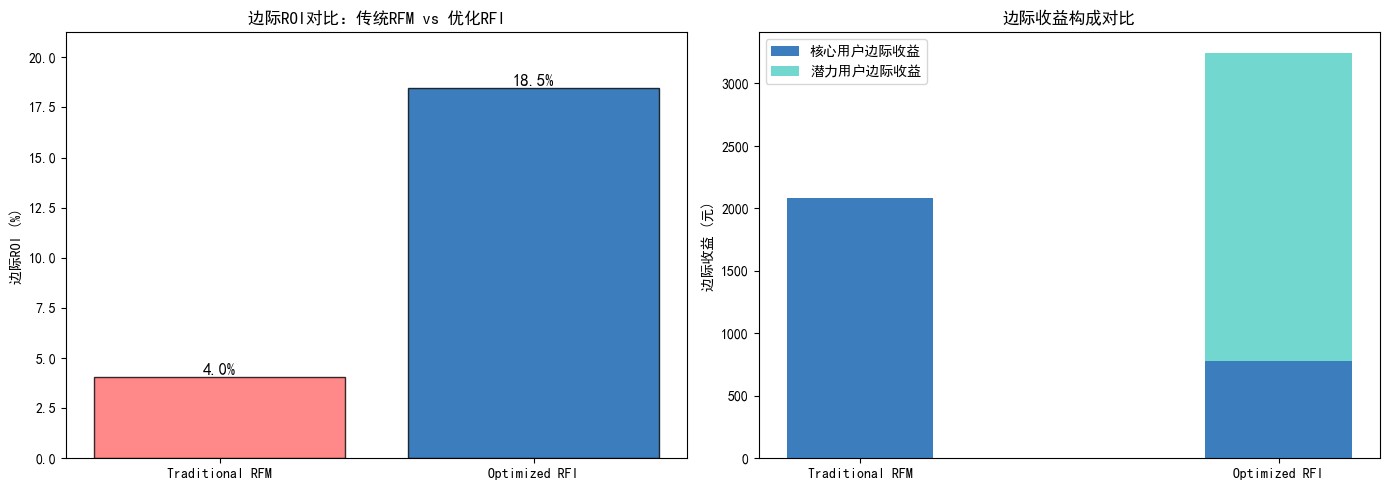

In [19]:
def calculate_roi(df, output_dir):
    save_dir = os.path.join(output_dir, "ROI_result")
    os.makedirs(save_dir, exist_ok=True)

    """ROI测算：传统RFM vs 优化RFM-I策略对比（边际收益法，参数可调）"""

    # ================= 可调整参数 =================
    total_budget = 10000          # 总预算（元）
    coupon_cost = 10              # 每张优惠券成本（元）
    aov = df['Average_Order_Value'].mean()  # 平均客单价（元）

    # 转化率假设
    # 核心用户
    core_natural = 0.25           # 核心用户自然转化率
    core_with_coupon = 0.30       # 核心用户发券后转化率
    # 潜力用户
    potential_natural = 0.01      # 潜力用户自然转化率
    potential_with_coupon = 0.20  # 潜力用户发券后转化率
    # 一般用户
    general_natural = 0.02        # 一般用户自然转化率
    # RFM前20%用户的转化率
    rfm20_natural = 0.20          # RFM高分用户自然转化率
    rfm20_with_coupon = 0.30      # 发券后转化率

    # 边际提升
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural

    # ================= RFM策略 =================
    top20_threshold = df['RFM_Score'].quantile(0.80)
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold]

    target_a_count = min( len(rfm_top20), total_budget // coupon_cost)
    cost_a = target_a_count * coupon_cost
    incremental_revenue_a = ( target_a_count * rfm20_lift * aov)

    roi_a = ((incremental_revenue_a - cost_a) / cost_a * 100) if cost_a > 0 else 0

    # ================= RFM-I策略 =================
    core_users = df[df['User_Segment'].isin(['核心VIP', '重要价值用户'])]
    potential_users = df[
        df['User_Segment'].isin(
            [
                '高意向待转化用户',
                '高潜沉睡用户',
                '犹豫型潜力用户',
                '高潜流失用户'
            ]
        )
    ]

    # 分配预算：优先核心用户（用80%预算），剩余给潜力用户
    core_count = min(len(core_users), int(total_budget * 0.8 / coupon_cost))
    remaining_budget = total_budget - core_count * coupon_cost
    potential_count = min(len(potential_users), remaining_budget // coupon_cost)
    target_b_count = core_count + potential_count
    cost_b = target_b_count * coupon_cost
    
    incremental_revenue_b = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_b = ((incremental_revenue_b - cost_b) / cost_b * 100) if cost_b > 0 else 0

    # ================= 输出结果 =================
    print("\n【假设参数】")
    print(f"  总预算: {total_budget}元")
    print(f"  优惠券成本: {coupon_cost}元/人")
    print(f"  平均客单价: {aov:.0f}元")

    print("\n【转化率假设】")
    print(
        f"  RFM前20%用户：自然转化率 "
        f"{rfm20_natural*100:.1f}%，"
        f"发券后 {rfm20_with_coupon*100:.1f}%，"
        f"边际提升 {rfm20_lift*100:.1f}%"
    )
    print(
        f"  核心用户：自然转化率 "
        f"{core_natural*100:.1f}%，"
        f"发券后 {core_with_coupon*100:.1f}%，"
        f"边际提升 {core_lift*100:.1f}%"
    )
    print(
        f"  潜力用户：自然转化率 "
        f"{potential_natural*100:.1f}%，"
        f"发券后 {potential_with_coupon*100:.1f}%，"
        f"边际提升 {potential_lift*100:.1f}%"
    )

    print("\n【传统RFM策略】")
    print(f"  目标用户数: {target_a_count}")
    print(f"  成本: {cost_a}元")
    print(
        f"  边际收益（增量）: "
        f"{incremental_revenue_a:.0f}元"
    )
    print(f"  边际ROI: {roi_a:.1f}%")

    print("\n【优化RFM-I策略】")
    print(f"  核心用户: {core_count}")
    print(f"  新挖掘潜力用户: {potential_count}")
    print(f"  总目标用户数: {target_b_count}")
    print(
        f"  实际成本: {cost_b}元 "
        f"(预算使用率: "
        f"{cost_b/total_budget*100:.1f}%)"
    )
    print(
        f"  边际收益（增量）: "
        f"{incremental_revenue_b:.0f}元"
    )
    print(f"  边际ROI: {roi_b:.1f}%")

    roi_summary = pd.DataFrame({
        '策略': ['传统 RFM', '优化 RFM-I'],
        '投放人数': [target_a_count, target_b_count],
        '投放成本': [cost_a, cost_b],
        '预计边际收益': [incremental_revenue_a, incremental_revenue_b],
        '边际ROI(%)': [roi_a, roi_b]
    }).round(2)
    
    display(roi_summary)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 边际ROI对比
    strategies = ['Traditional RFM', 'Optimized RFI']
    rois = [roi_a, roi_b]
    colors = ['#FF6B6B', '#0B5CAD']

    bars = axes[0].bar(strategies, rois, color=colors, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('边际ROI (%)')
    axes[0].set_ylim(top= max(rois)*1.15)
    axes[0].set_title('边际ROI对比：传统RFM vs 优化RFI', fontsize=12)
    for bar, roi in zip(bars, rois):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'{roi:.1f}%', ha='center',va='bottom', fontsize=12, fontweight='bold')

    # 边际收益构成对比
    x = np.arange(2)
    width = 0.35
    core_marginal = [incremental_revenue_a, core_count * core_lift * aov]
    potential_marginal = [0, potential_count * potential_lift * aov]

    axes[1].bar(x, core_marginal, width, label='核心用户边际收益', color='#0B5CAD', alpha=0.8)
    axes[1].bar(x, potential_marginal, width, bottom=core_marginal, label='潜力用户边际收益', color='#4ECDC4', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylabel('边际收益 (元)')
    axes[1].set_title('边际收益构成对比', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/roi_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    return {
        'strategy_a': {
            'target_count': int(target_a_count),
            'cost': cost_a,
            'incremental_revenue': incremental_revenue_a,
            'marginal_roi': roi_a
        },
        'strategy_b': {
            'core_count': int(core_count),
            'potential_count': int(potential_count),
            'total_count': int(target_b_count),
            'actual_cost': cost_b,
            'budget_used_ratio': cost_b / total_budget,
            'incremental_revenue': incremental_revenue_b,
            'marginal_roi': roi_b
        },
        'params': {
            'budget': total_budget,
            'coupon_cost': coupon_cost,
            'aov': aov,
            'rfm20_lift': rfm20_lift,
            'core_lift': core_lift,
            'potential_lift': potential_lift
        }
    }

roi_results = calculate_roi(df, OUTPUT_DIR)

## 9. 总结

传统 RFM 模型仅依托历史交易维度评估用户价值，无法有效覆盖高浏览意向、高消费能力但尚未充分转化的潜力客群，用户价值评估较为片面、潜力人群识别不足。

本项目在经典 RFM 模型框架下，引入用户意向评分、转化摩擦系数、收入层级三个维度指标，构建RFM-I用户价值分层模型。优化后的模型可进一步识别核心VIP、高潜流失用户、犹豫型潜力用户、高意向待转化用户及高潜沉睡用户等重点运营人群，为差异化用户触达提供分层依据。

ROI情景模拟测算结果显示，基于RFM-I分层的差异化触达策略预计边际 ROI 为18.47%，较传统 RFM 策略的4.04%有显著提升，验证了结合用户意向与购买力背景开展精细化运营，可有效优化营销资源配置效率。

需说明的是，上述测算是基于理想假设的情景模拟结果，其真实业务增益仍需通过正式A/B实验验证。
